# 35. Square-Dalitz histogram efficiency/background from arrays

**Objectives:**
- Build `SquareDalitzHistogramEfficiency` and `SquareDalitzHistogramBackground`
  directly from hand-built numpy arrays in `(m', theta')`, with no ROOT file.
- Use the efficiency map inside a `FitSession` (`efficiency=`).
- Use the background map inside a `FitSession` via `BackgroundSpec`.

Run cells top to bottom in a fresh kernel. Masses are in GeV, invariants in GeV²,
daughter indices start at zero. See `docs/backgrounds_and_vetoes.md`,
"Importing Square-Dalitz histogram densities".

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from dalitzplotfitter import (
    BackgroundSpec, DecayChannel, DecayModel, FitSession, NonResonant,
    Parameter, RealImag, Resonance, SquareDalitzHistogramBackground,
    SquareDalitzHistogramEfficiency, ToyBackground, generate_toy,
)

## 1. A small model

`D+ -> pi- pi+ pi+` with one `rho(770)` resonance and a floatable non-resonant
coefficient, normalized on the Square-Dalitz grid.

In [2]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
x = Parameter.coefficient("NR.x", 0.55, owner="NR", bounds=(-2, 2), step=0.02)
y = Parameter.coefficient("NR.y", 0.30, owner="NR", bounds=(-2, 2), step=0.02)
components = [
    Resonance("rho", (0, 1), RealImag(1, 0), mass=0.7753, width=0.1491, spin=1),
    NonResonant(RealImag(x, y), name="NR"),
]
model = DecayModel(
    channel, components, normalization_method="square-dalitz",
    normalization_resolution=100, normalization_pair=(0, 1),
)
truth = {p.name: p.value for p in model.parameters}

## 2. Piecewise-constant efficiency map from a numpy array

A `4 x 4` grid in `(m', theta')` covering the full unit square, values in
`[0, 1]`. `pair=(0, 1)` matches `normalization_pair` above.

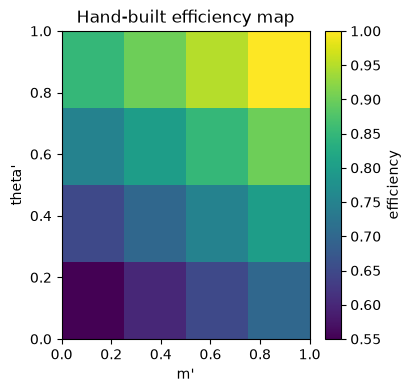

In [3]:
mprime_edges = np.linspace(0.0, 1.0, 5)
thetaprime_edges = np.linspace(0.0, 1.0, 5)
efficiency_values = np.array([
    [0.55, 0.65, 0.75, 0.85],
    [0.60, 0.70, 0.80, 0.90],
    [0.65, 0.75, 0.85, 0.95],
    [0.70, 0.80, 0.90, 1.00],
])
efficiency = SquareDalitzHistogramEfficiency(
    mprime_edges=mprime_edges, thetaprime_edges=thetaprime_edges,
    values=efficiency_values,
    mother_mass=channel.parent_mass, masses=channel.daughter_masses,
    pair=(0, 1), clip=True,
)

plt.figure(figsize=(4, 4))
plt.imshow(efficiency_values.T, origin="lower", extent=(0, 1, 0, 1), aspect="auto")
plt.xlabel("m'")
plt.ylabel("theta'")
plt.title("Hand-built efficiency map")
plt.colorbar(label="efficiency")
plt.show()

## 3. A background map from a numpy array

The background is a piecewise-constant Square-Dalitz *density* in
`dm' dtheta'`. `divide_jacobian=True` converts it to a density in ordinary
Dalitz coordinates before it enters the fit PDF (`docs/backgrounds_and_vetoes.md`);
`generation_value` (unused for fitting here) never applies that conversion.

In [4]:
background_values = np.array([
    [1.0, 1.0, 1.0, 1.0],
    [1.0, 2.0, 2.0, 1.0],
    [1.0, 2.0, 2.0, 1.0],
    [1.0, 1.0, 1.0, 1.0],
])
background = SquareDalitzHistogramBackground(
    mprime_edges=mprime_edges, thetaprime_edges=thetaprime_edges,
    values=background_values,
    mother_mass=channel.parent_mass, masses=channel.daughter_masses,
    pair=(0, 1), divide_jacobian=True,
)

## 4. Fit with both maps in a `FitSession`

We generate a toy under the efficiency map with a small background admixture
and fit the signal fraction with both maps supplied to `FitSession`.

In [5]:
fraction = Parameter("signal_fraction", 0.75, bounds=(0.05, 0.99), step=0.02)
data = generate_toy(
    model, 3000, parameters=truth, seed=35, efficiency=efficiency,
    signal_fraction=0.80,
    backgrounds=(ToyBackground("comb", background),),
    inverse_resolution=384, include_momenta=False,
)
session = FitSession(
    model, data, efficiency=efficiency, signal_fraction=fraction,
    backgrounds=(BackgroundSpec("comb", background),),
)
result = session.fit(simplex=True, ncall=5000)
session.report(result)
assert result.valid

valid=True  NLL=4107.164868
parameter                           value            error
NR.x                              0.65192        0.0227478
NR.y                             0.448255        0.0202837
signal_fraction                      0.99       0.00505046


Fit fractions (physical)
component                    fraction [%]
rho                                61.503
NR                                 38.497
sum                               100.000


## Try it yourself

1. Change `pair=(0, 1)` to `pair=(1, 2)` with `folded=True` and confirm the
   constructor rejects `thetaprime_edges` that extend past 0.5 unless the
   edges themselves already stop at 0.5.
2. Try `interpolation="linear"` on the efficiency map and compare the fitted
   `signal_fraction`.
3. Read the raw density at a few `(m', theta')` points with `efficiency(data)`
   directly, without going through `FitSession`.

## Continue learning

Next: [Histogram maps from a ROOT file](tutorial_36_histogram_maps_from_root.ipynb).
Reference: [backgrounds and vetoes](../../docs/backgrounds_and_vetoes.md).

Return to [the course guide](TUTORIALS.md).